---
title: "QoG Basic Cross-Sectional Model Example"
format:
  html:
    embed-resources: true
    toc: true
jupyter: python3
execute:
  echo: true
  warning: false
  message: false
---

## Introduction

This notebook uses the QoG Basic cross-sectional dataset to illustrate a multivariate model of human development. For licensing reasons, the dataset is not redistributed here; instead, the code downloads the CSV directly from the official QoG data repository at render time.

Dataset citation in APA 7 format:

Dahlberg, S., Sundström, A., Holmberg, S., Rothstein, B., Alvarado Pachon, N., Saidi Phiri, V., Chen, C., & Liu, Z. (2026). *The Quality of Government Basic Dataset, Version Jan26*. University of Gothenburg: The Quality of Government Institute. https://www.gu.se/en/quality-government. https://doi.org/10.18157/qogbasjan26

The dependent variable is `undp_hdi`, the Human Development Index. The model uses three theoretically relevant predictors:

- `icrg_qog`: a continuous quality of government indicator. Better institutional quality should be associated with better development outcomes.
- `wdi_region`: a multinomial World Bank region variable. Region captures broad historical, economic, and geopolitical context.
- `bmr_dem`: a binary democracy indicator. Democratic accountability may influence public investment and welfare responsiveness.

The proposed model is:

```text
Human development = quality of government + world region + democracy
```

## Model Diagram

[![](https://mermaid.ink/img/pako:eNqVU1tr2zAU_itCoZCCk0m-xIlWAqV52GCMbYUWVvdBsZRYxJbMsZzWDfnvk5M4l7UvlcHoHOm7nCNpg1MjJGZ4CbzM0I8_iUZuCAUytcroXWafq-r5ftOt5nlTqQo93cynv0AKlVoDFTILlNUF10jItcxNWUhtb77Mp897_HveLnuaXV2h71rIUrqftuiBg-LzXFanHWpN-79rnivbtIJLs5agW6Xr8z1-_9FALhDIpRO7WAr6M1mYFHjaXHelHaRn74TPnK_pU1vvtw8rfP6P6c5ovS_00joaDKYt1YXXj5LBZdLZ6hQc-093ZOjeNrnSy8PZuECeDmah8pz1FpP28yoLZiVZL03Tw3wgeJVxAN4wFKHonKL1eEDvxhEdBIGXmtwA6xFCLiH-5yHBZyHiaExQQgQ9Qvx5SKNRh3JkZ42acVhJQLcA5qVrGOq7G6ZSWTliDhZxi8jhgrjl1f1OjXjU81En4ax0nXtRwmbML1-_Jhp77tUogZmFWnq4kFDwNsSbli7BNpOFTDBzU-GMJDjRW4cpuf5rTNHBwNTLDLMFzysX1aXgVs4Ud0_ttKW9lXBnam0xo2RHgdkGv7oo8IfxeBxTGoXxOGo7gRvMonDoExL4lE7iiEzi0Wjr4bedKhlOwpCQUTShcRyOQhpu_wFM_jpl?type=png)](https://mermaid.live/edit#pako:eNqVU1tr2zAU_itCoZCCk0m-JdFKoDQPG4yxrdDC6j4olhKL2JI5ltO6If99chLnsvalMhjp6HyXcyRtcGqExAwvgZcZ-vEn0cgNoUCmVhm9i-xjVT3fJ91qnjeVqtDTzXz6C6RQqTVQIbNAWV1wjYRcy9yUhdT25st8-rzHv-ftoqfZ1RX6roUspftpix44KD7PZXXKUGva_13zXNmmFVyatQTdKl2f5_j9RwO5QCCXTuxiK-jPZGFS4Glz3ZV2kJ69Ez5zvqZPbb3fPqzw-T-mO6P1vtBL62gwmLZUF14_CgaXQWerU3DsP92RoXvb5EovD2fjFvJ0MAuV56y3mLSfV1kwK8l6aZoe5gPBq4wD8IahCEXnFK3HA3o3juggCLzU5AZYjxByCfE_Dwk-CxFHY4ISIugR4s9DGsUdypGdNWrGYSUB3QKYl65hqO9umEpl5Yg5WMQtIocL4rZX9zs14lHPR52Es9J17kUJmzG_fP2aaOy5V6MEZhZq6eFCQsHbJd60dAm2mSxkgpmbCmckwYneOkzJ9V9jig4Gpl5mmC14XrlVXQpu5Uxx99SKYxTaawl3ptYWs2hHgdkGv2JGA384Go9HlEbhaBy1ncCNywmHPiGBT-lkFJHJKI63Hn7bqZLhJAwJiaMojsc0ID7d_gNVmTp5)

## Data Import and Variable Selection

In [1]:
import pandas as pd

url = "https://www.qogdata.pol.gu.se/data/qog_bas_cs_jan26.csv"

variables = {
    "cname": "Country",
    "ccodealp": "ISO alpha-3 country code",
    "undp_hdi": "Human Development Index",
    "icrg_qog": "Quality of government",
    "wdi_region": "World Bank region",
    "bmr_dem": "Democracy indicator",
}

df = pd.read_csv(url)
model_df = df[list(variables)].copy()
model_df = model_df.rename(columns=variables)

model_df["World Bank region"] = model_df["World Bank region"].astype("category")
model_df["Democracy indicator"] = model_df["Democracy indicator"].map(
    {0: "Non-democracy", 1: "Democracy"}
).astype("category")

complete_model_df = model_df.dropna().copy()

summary = pd.DataFrame(
    {
        "measure": [
            "Rows in full dataset",
            "Variables in full dataset",
            "Rows after selecting model variables",
            "Complete cases for proposed model",
            "Countries in complete-case model data",
        ],
        "value": [
            df.shape[0],
            df.shape[1],
            model_df.shape[0],
            complete_model_df.shape[0],
            complete_model_df["Country"].nunique(),
        ],
    }
)

display(summary)
display(model_df.head())
display(model_df.describe(include="all"))

,measure,value
0,Rows in full dataset,194
1,Variables in full dataset,320
2,Rows after selecting model variables,194
3,Complete cases for proposed model,137
4,Countries in complete-case model data,137


,Country,ISO alpha-3 country code,Human Development Index,Quality of government,World Bank region,Democracy indicator
0,Afghanistan,AFG,0.495,NaN,4.0,Non-democracy
1,Albania,ALB,0.806,0.442130,2.0,Democracy
2,Algeria,DZA,0.761,0.434028,4.0,Non-democracy
3,Andorra,AND,0.893,NaN,2.0,Democracy
4,Angola,AGO,0.615,0.418981,7.0,Non-democracy


,Country,ISO alpha-3 country code,Human Development Index,Quality of government,World Bank region,Democracy indicator
count,194,194,190.000000,139.000000,192.0,193
unique,194,194,NaN,NaN,7.0,2
top,Afghanistan,AFG,NaN,NaN,2.0,Democracy
freq,1,1,NaN,NaN,52.0,117
mean,NaN,NaN,0.736953,0.542732,NaN,NaN
std,NaN,NaN,0.150338,0.199414,NaN,NaN
min,NaN,NaN,0.385000,0.055556,NaN,NaN
25%,NaN,NaN,0.622000,0.416667,NaN,NaN
50%,NaN,NaN,0.761000,0.500000,NaN,NaN
75%,NaN,NaN,0.852750,0.667824,NaN,NaN


## Model Specification

The corresponding regression formula is:

```text
undp_hdi ~ icrg_qog + C(wdi_region) + bmr_dem
```

In the modified dataset above, this means estimating human development as a function of quality of government, region, and democracy status.

--- Descriptive Statistics for Human Development Index ---
count    190.000000
mean       0.736953
std        0.150338
min        0.385000
25%        0.622000
50%        0.761000
75%        0.852750
max        0.967000
Name: Human Development Index, dtype: float64
Variance:            0.0226
Skewness:            -0.4268
Kurtosis:            -0.7372
Missing Values:      4


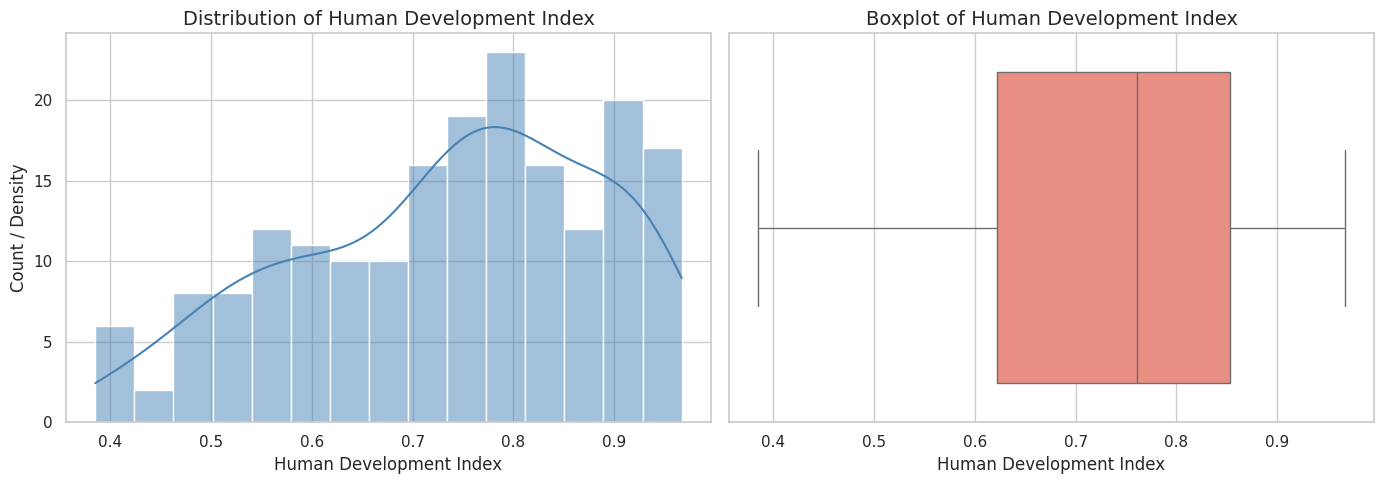

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Descriptive Statistics
dv_col = "Human Development Index"

print(f"--- Descriptive Statistics for {dv_col} ---")
print(model_df[dv_col].describe())
print(f"Variance:            {model_df[dv_col].var():.4f}")
print(f"Skewness:            {model_df[dv_col].skew():.4f}")
print(f"Kurtosis:            {model_df[dv_col].kurt():.4f}")
print(f"Missing Values:      {model_df[dv_col].isna().sum()}")

# 2. Visualizations
# Set the plot style for clear presentation
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: Histogram with Kernel Density Estimate (KDE)
sns.histplot(
    data=model_df, x=dv_col, kde=True, ax=axes[0], color="steelblue", bins=15
)
axes[0].set_title(f"Distribution of {dv_col}", fontsize=14)
axes[0].set_xlabel(dv_col, fontsize=12)
axes[0].set_ylabel("Count / Density", fontsize=12)

# Right subplot: Horizontal Boxplot to inspect quartiles and potential outliers
sns.boxplot(data=model_df, x=dv_col, ax=axes[1], color="salmon")
axes[1].set_title(f"Boxplot of {dv_col}", fontsize=14)
axes[1].set_xlabel(dv_col, fontsize=12)

# Adjust layout to prevent any overlapping or truncation of labels
plt.tight_layout()
plt.show()